In [1]:
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import torch
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import pandas as pd
from collections import defaultdict
import scipy

rng = np.random.default_rng(seed=123)

In [2]:
def setup_device():
    try:
        import torch_directml

        device = torch_directml.device()
        backend = "directml"    
    except ImportError:
        if torch.cuda.is_available():
            device = torch.device("cuda")
            backend = "cuda"
        else:
            device = torch.device("cpu")
            backend = "cpu"
    return device


In [3]:
device = setup_device()

In [4]:
class SimpleNN(nn.Module):
    def __init__(self, d):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(d * d, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, d),
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [5]:
import numpy as np

def random_matrix_with_condition(m, n=None, cond_number=10.0):
    """
    Generate an m x n random matrix with approximate condition = cond_number,
    using singular values drawn uniformly between 1/sqrt(cond) and sqrt(cond).
    """
    if n is None:
        n = m
        
    # random orthogonal factors from normal distribution
    U, _ = np.linalg.qr(np.random.randn(m, m))
    V, _ = np.linalg.qr(np.random.randn(n, n))

    min_dim = min(m, n)

    # limits for uniform singular values
    s_min = 1.0 / np.sqrt(cond_number)
    s_max = np.sqrt(cond_number)

    # draw singular values uniform in [s_min, s_max]
    s = np.concatenate([np.array([s_min, s_max]), np.random.uniform(low=s_min, high=s_max, size=min_dim-2)])

    # build Sigma
    Sigma = np.zeros((m, n))
    Sigma[:min_dim, :min_dim] = np.diag(s)

    return U @ Sigma @ V.T



In [6]:
def generate_matrix(d, block_size, eps=None, lam=1, schur=False, cond=100):
    """
    Generuje macierz testową o rozmiarze `d x d` z kontrolowaną strukturą.

    Parametry:
    - d (int): wymiar macierzy (liczba wierszy/kolumn).
    - block_size (int): liczba pozycji na nadprzekątnej, które zostaną ustawione
        na 1 (losowo wybrane indeksy). Używane do budowy macierzy Jordanowskiej.
    - mode (str): tryb generacji macierzy pomocniczej `S`. Obsługiwane wartości:
        "random", "int", "upper", "lower", "ortho". Określa, jakiego rodzaju
        macierz S zostanie wygenerowana (np. ortogonalna, trójkątna itp.).
    - eps (float|None): jeśli nie None, dodaje małą losową perturbację do macierzy
        J (skaluje losowymi wartościami z [0, eps)). Przydatne do testów stabilności.
    - lam (float): wartość dodawana do elementów diagonalnych macierzy J (domyślnie 1).
    - value_range (int|float|None): skala wartości używana przy generacji macierzy S;
        jeśli None, wartość dobierana jest zależnie od `mode`.
    - schur (bool): jeśli True, zwraca postać Schura macierzy X zamiast X bezpośrednio.

    Zwraca:
    - X (np.ndarray): macierz wynikowa rozmiaru (d, d). Jeśli `schur`==True, zwracana
        jest macierz otrzymana z dekompozycji Schura.

    Uwaga:
    Funkcja tworzy macierz J (prawie Jordanowską) z nadprzekątną ustawioną zgodnie
    z `block_size`, a następnie wykonuje podobieństwo X = S @ J @ S^{-1}, gdzie S
    jest generowane według `mode`.
    """
    indexes = np.random.choice(d-1, size=block_size, replace=False)
    # indexes = list(range(block_size))
    super_diag = np.zeros(d-1)
    for index in indexes:
        super_diag[index] = 1
    J = lam * np.eye(d) + np.diag(super_diag, k=1)
    if eps is not None:
        J += eps * np.random.randn(d, d)

    S = random_matrix_with_condition(d, cond_number=cond)
    X = S @ J @ np.linalg.inv(S)
    if schur:
        return scipy.linalg.schur(X)[0]
    else:
        return X


def generate_testset(d, size_per_class, mode="random", eps=None, cond=100):
    """
    Generuje zbiór testowy macierzy wraz z etykietami klas.

    Parametry:
    - d (int): wymiar macierzy (liczba klas również wynika z `d`).
    - size_per_class (int): liczba przykładów (macierzy) generowanych dla każdej klasy.
    - mode (str): tryb przekazywany dalej do `generate_matrix` (jak wyżej).
    - eps (float|None): opcjonalna perturbacja przekazywana do `generate_matrix`.
    - schur (bool): jeśli True, każda macierz będzie zwrócona w postaci Schura.

    Zwraca:
    - X (np.ndarray): tablica kształtu `(size_per_class * d, d, d)`, gdzie pierwszym
      wymiarem indeksujemy próbki.
    - y (list[int]): lista etykiet (0..d-1) odpowiadająca klasom każdej macierzy w X.

    Zachowanie:
    Dla każdej etykiety `label` od 0 do `d-1` generowane jest `size_per_class`
    macierzy przy użyciu `generate_matrix(d, label, ...)`. Etykieta przypisywana jest
    zgodnie z wartością `label` (może reprezentować np. rozmiar bloku/Jordanowską pozycję).
    """
    X = np.ndarray(shape=(size_per_class * d, d, d))
    y = []

    idx = 0
    for label in range(d):
        for _ in range(size_per_class):
            X[idx] = generate_matrix(d, label, eps=eps, cond=cond)
            idx += 1
            y.append(label)

    return X, y

In [22]:
def generate_trainset(d, size_per_class=50_000, cond_min = 1, cond_max = 101, eps=None):
    X = np.ndarray(shape=(size_per_class * d, d, d))
    y = []

    log_cond_min = np.log(cond_min)
    log_cond_max = np.log(cond_max)
    conds = []

    idx = 0
    for label in range(d):
        for _ in range(size_per_class):
            cond = int(np.exp(np.random.rand() * (log_cond_max - log_cond_min) + log_cond_min))
            conds.append(cond)
            X[idx] = generate_matrix(d, label, eps=eps, schur=False, cond=cond)
            idx += 1
            y.append(label)

    return X, y, conds

In [23]:
def generate_and_train_model(X, y, device, verbose=1, epochs=50):
    # --- Dataset setup ---
    d = X[0].shape[0]
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=21
    )

    # --- Convert to tensors ---
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)

    # --- DataLoaders ---
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    # --- Model, Loss, Optimizer ---
    model = SimpleNN(d).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # --- Early Stopping setup ---
    best_val_acc = 0.0
    patience = 5
    counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        # Initialize running loss for the epoch
        running_loss = 0.0
        counter = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            # Accumulate training loss
            running_loss += loss.item() * xb.size(0)
            counter += yb.size(0)

        # Calculate average training loss for the epoch
        train_loss = running_loss / counter

        # --- Validation Loop ---
        model.eval()
        correct, total = 0, 0
        # Initialize running validation loss
        val_running_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                # Calculate validation loss
                val_loss = criterion(preds, yb)
                val_running_loss += val_loss.item() * xb.size(0)

                pred_labels = preds.argmax(1)
                correct += (pred_labels == yb).sum().item()
                total += yb.size(0)
        
        # Calculate average validation loss for the epoch
        avg_val_loss = val_running_loss / total
        val_acc = correct / total

        if verbose:
            print(f"Epoch {epoch+1:02d} - Train Loss: {train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # --- Early Stopping ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
            best_weights = model.state_dict()
        else:
            counter += 1
            if epoch == 10:
                counter = 0
            if counter >= patience and epoch > 10:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    # --- Restore best model ---
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model

In [34]:
X_train, y_train, conds_train = generate_trainset(5, cond_min=1, cond_max=101)

In [35]:
model = generate_and_train_model(X_train, y_train, device)
torch.save(model.state_dict(), f"sandbox/model_4a/1_100.pth")

Epoch 01 - Train Loss: 0.9808 | Val Loss: 0.9438 | Val Acc: 0.5358
Epoch 02 - Train Loss: 0.9449 | Val Loss: 0.9176 | Val Acc: 0.5369
Epoch 03 - Train Loss: 0.8932 | Val Loss: 0.8773 | Val Acc: 0.5672
Epoch 04 - Train Loss: 0.8399 | Val Loss: 0.7996 | Val Acc: 0.6166
Epoch 05 - Train Loss: 0.7291 | Val Loss: 0.7145 | Val Acc: 0.6588
Epoch 06 - Train Loss: 0.6871 | Val Loss: 0.6761 | Val Acc: 0.6740
Epoch 07 - Train Loss: 0.6540 | Val Loss: 0.6642 | Val Acc: 0.6826
Epoch 08 - Train Loss: 0.6351 | Val Loss: 0.6421 | Val Acc: 0.6906
Epoch 09 - Train Loss: 0.6291 | Val Loss: 0.6636 | Val Acc: 0.6806
Epoch 10 - Train Loss: 0.6123 | Val Loss: 0.6482 | Val Acc: 0.6909
Epoch 11 - Train Loss: 0.6032 | Val Loss: 0.6273 | Val Acc: 0.6982
Epoch 12 - Train Loss: 0.5955 | Val Loss: 0.6527 | Val Acc: 0.6898
Early stopping at epoch 12


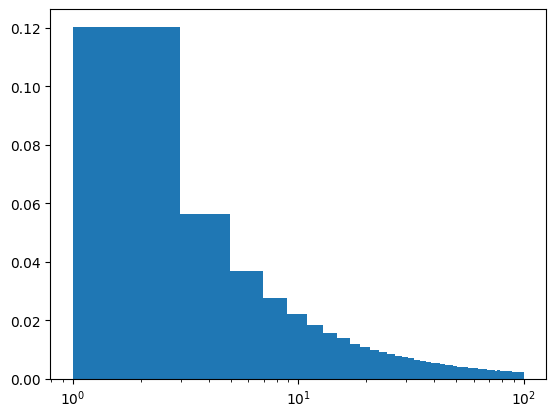

In [41]:
plt.hist(conds_train, bins=50, density=True)
plt.xscale('log')
plt.show()